In [18]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve

In [19]:
# Load the dataset
# Assuming the dataset is already preprocessed and has a 'label' column for binary classification.
# Replace with your actual data loading step
df = pd.read_csv('cicids2017_cleaned.csv')


In [20]:
df.shape

(2520751, 53)

In [21]:
df.head(5)

,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,...,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Max,Active Min,Idle Mean,Idle Max,Idle Min,Attack Type
0,22,1266342,41,2664,456,0,64.975610,109.864573,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
1,22,1319353,41,2664,456,0,64.975610,109.864573,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
2,22,160,1,0,0,0,0.000000,0.000000,0,0,...,243,0,32,0.0,0,0,0.0,0,0,Normal Traffic
3,22,1303488,41,2728,456,0,66.536585,110.129945,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
4,35396,77,1,0,0,0,0.000000,0.000000,0,0,...,290,0,32,0.0,0,0,0.0,0,0,Normal Traffic


In [22]:
# Example of preprocessing
# You might need to drop non-numeric columns or fill missing values, etc.
# Assume the target column is 'label' and the rest are features.
X = df.drop(columns=['Attack Type'])  # Features
y = df['Attack Type']  # Target

In [23]:
# Manually map the labels to numeric values
y = y.map({'Normal Traffic': 0, 'Attack': 1})

In [26]:
y.head(3)

0    0.0
1    0.0
2    0.0
Name: Attack Type, dtype: float64

In [27]:
X.head(3)

,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,...,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Max,Active Min,Idle Mean,Idle Max,Idle Min
0,22,1266342,41,2664,456,0,64.97561,109.864573,976,0,...,29200,243,24,32,0.0,0,0,0.0,0,0
1,22,1319353,41,2664,456,0,64.97561,109.864573,976,0,...,29200,243,24,32,0.0,0,0,0.0,0,0
2,22,160,1,0,0,0,0.00000,0.000000,0,0,...,290,243,0,32,0.0,0,0,0.0,0,0


In [28]:
# Split the dataset into train, validation, and test sets (80%, 10%, 10%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [29]:
# Standardize the features (important for neural networks)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Ensure the data type is float32 (required by TensorFlow)
X_train = X_train.astype(np.float32)
X_val = X_val.astype(np.float32)
X_test = X_test.astype(np.float32)

# Reshape the data for RNN (samples, timesteps, features)
# For simplicity, we'll assume 1 timestep (can be modified for more complex datasets)
X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_val = X_val.reshape(X_val.shape[0], 1, X_val.shape[1])
X_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

# Build the RNN model
model = Sequential()

# Add an RNN layer
model.add(SimpleRNN(units=64, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))

# Add dropout to avoid overfitting
model.add(Dropout(0.5))

# Add a Dense layer for binary classification
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_data=(X_val, y_val))

# Make predictions
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)  # Convert predictions to binary class labels

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print evaluation metrics
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')
print(f'Confusion Matrix:\n{conf_matrix}')

Epoch 1/10


c:\Users\user15\Anaconda3\envs\vivek\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


31510/31510 ━━━━━━━━━━━━━━━━━━━━ 36s 1ms/step - accuracy: 0.8314 - loss: nan - val_accuracy: 0.8296 - val_loss: nan
Epoch 2/10
31510/31510 ━━━━━━━━━━━━━━━━━━━━ 35s 1ms/step - accuracy: 0.8312 - loss: nan - val_accuracy: 0.8296 - val_loss: nan
Epoch 3/10
31510/31510 ━━━━━━━━━━━━━━━━━━━━ 35s 1ms/step - accuracy: 0.8316 - loss: nan - val_accuracy: 0.8296 - val_loss: nan
Epoch 4/10
31510/31510 ━━━━━━━━━━━━━━━━━━━━ 35s 1ms/step - accuracy: 0.8311 - loss: nan - val_accuracy: 0.8296 - val_loss: nan
Epoch 5/10
31510/31510 ━━━━━━━━━━━━━━━━━━━━ 35s 1ms/step - accuracy: 0.8312 - loss: nan - val_accuracy: 0.8296 - val_loss: nan
Epoch 6/10
31510/31510 ━━━━━━━━━━━━━━━━━━━━ 35s 1ms/step - accuracy: 0.8313 - loss: nan - val_accuracy: 0.8296 - val_loss: nan
Epoch 7/10
31510/31510 ━━━━━━━━━━━━━━━━━━━━ 35s 1ms/step - accuracy: 0.8313 - loss: nan - val_accuracy: 0.8296 - val_loss: nan
Epoch 8/10
31510/31510 ━━━━━━━━━━━━━━━━━━━━ 35s 1ms/step - accuracy: 0.8311 - loss: nan - val_accuracy: 0.8296 - val_loss:

c:\Users\user15\Anaconda3\envs\vivek\lib\site-packages\sklearn\utils\_array_api.py:399: RuntimeWarning: invalid value encountered in cast
  return x.astype(dtype, copy=copy, casting=casting)


ValueError: Input y_true contains NaN.

In [ ]:
# Plot Confusion Matrix
plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

In [ ]:
# Plot Precision-Recall Curve
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_pred)

plt.figure(figsize=(6, 6))
plt.plot(recall_curve, precision_curve, color='green', label=f'Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.show()

In [32]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import LabelEncoder

# Load the dataset
# Replace with your actual data loading step
df = pd.read_csv('cicids2017_cleaned.csv')

# Example of preprocessing
X = df.drop(columns=['Attack Type'])  # Features
y = df['Attack Type']  # Target

# Encode the target labels using LabelEncoder (converts string to numeric labels)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)  # Converts 'Normal Traffic' to 0, 'Attack' to 1

# Split the dataset into train, validation, and test sets (80%, 10%, 10%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Standardize the features (important for neural networks)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Ensure the data type is float32 (required by TensorFlow)
X_train = X_train.astype(np.float32)
X_val = X_val.astype(np.float32)
X_test = X_test.astype(np.float32)

# Reshape the data for RNN (samples, timesteps, features)
X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_val = X_val.reshape(X_val.shape[0], 1, X_val.shape[1])
X_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

# Check and handle NaN values in the target variable (y_test)
if np.isnan(y_test).any():
    print(f"NaN values detected in y_test. Removing rows with NaN...")
    y_test = y_test[~np.isnan(y_test)]  # Remove NaN entries from y_test
    X_test = X_test[~np.isnan(y_test)]  # Remove corresponding rows from X_test


# Check and handle NaN values in the target variable (y_test)
'''if y_test.isnan().any():
    print(f"NaN values detected in y_test. Removing rows with NaN...")
    y_test = y_test.dropna()
    X_test = X_test[y_test.index]  # Drop corresponding rows from X_test'''

# Build the RNN model
model = Sequential()

# Add an RNN layer
model.add(SimpleRNN(units=64, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))

# Add dropout to avoid overfitting
model.add(Dropout(0.5))

# Add a Dense layer for binary classification
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_data=(X_val, y_val))

# Make predictions
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int).flatten()  # Convert predictions to binary class labels and flatten to 1D array

# Ensure y_test is 1D
y_test = y_test.flatten()

# Check for NaN values in y_pred
if np.isnan(y_pred).any():
    print(f"NaN values detected in y_pred. Replacing with 0...")
    y_pred = np.nan_to_num(y_pred)  # Replace NaN values with 0 (or another value if needed)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print evaluation metrics
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')
print(f'Confusion Matrix:\n{conf_matrix}')

# Plot Confusion Matrix
plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()

# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

# Plot Precision-Recall Curve
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_pred)

plt.figure(figsize=(6, 6))
plt.plot(recall_curve, precision_curve, color='green', label=f'Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.show()


c:\Users\user15\Anaconda3\envs\vivek\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
31510/31510 ━━━━━━━━━━━━━━━━━━━━ 37s 1ms/step - accuracy: 0.0037 - loss: -188107.0469 - val_accuracy: 0.0037 - val_loss: -1525435.8750
Epoch 2/10
31510/31510 ━━━━━━━━━━━━━━━━━━━━ 35s 1ms/step - accuracy: 0.0037 - loss: -2392565.0000 - val_accuracy: 0.0037 - val_loss: -5726589.0000
Epoch 3/10
31510/31510 ━━━━━━━━━━━━━━━━━━━━ 35s 1ms/step - accuracy: 0.0037 - loss: -7250498.5000 - val_accuracy: 0.0037 - val_loss: -12551417.0000
Epoch 4/10
31510/31510 ━━━━━━━━━━━━━━━━━━━━ 35s 1ms/step - accuracy: 0.0036 - loss: -14717525.0000 - val_accuracy: 0.0037 - val_loss: -21987198.0000
Epoch 5/10
31510/31510 ━━━━━━━━━━━━━━━━━━━━ 35s 1ms/step - accuracy: 0.0036 - loss: -24827396.0000 - val_accuracy: 0.0037 - val_loss: -34025236.0000
Epoch 6/10
31510/31510 ━━━━━━━━━━━━━━━━━━━━ 35s 1ms/step - accuracy: 0.0036 - loss: -37503008.0000 - val_accuracy: 0.0037 - val_loss: -48667412.0000
Epoch 7/10
31510/31510 ━━━━━━━━━━━━━━━━━━━━ 35s 1ms/step - accuracy: 0.0037 - loss: -52786728.0000 - val_accurac

ValueError: Target is multiclass but average='binary'. Please choose another average setting, one of [None, 'micro', 'macro', 'weighted'].

Epoch 1/10


c:\Users\user15\Anaconda3\envs\vivek\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


31510/31510 ━━━━━━━━━━━━━━━━━━━━ 37s 1ms/step - accuracy: 0.0036 - loss: -153829.6094 - val_accuracy: 0.0037 - val_loss: -1314866.0000
Epoch 2/10
31510/31510 ━━━━━━━━━━━━━━━━━━━━ 35s 1ms/step - accuracy: 0.0037 - loss: -2106404.5000 - val_accuracy: 0.0037 - val_loss: -5188641.0000
Epoch 3/10
31510/31510 ━━━━━━━━━━━━━━━━━━━━ 35s 1ms/step - accuracy: 0.0037 - loss: -6616679.0000 - val_accuracy: 0.0037 - val_loss: -11595287.0000
Epoch 4/10
31510/31510 ━━━━━━━━━━━━━━━━━━━━ 35s 1ms/step - accuracy: 0.0036 - loss: -13663481.0000 - val_accuracy: 0.0037 - val_loss: -20519410.0000
Epoch 5/10
31510/31510 ━━━━━━━━━━━━━━━━━━━━ 35s 1ms/step - accuracy: 0.0036 - loss: -23202412.0000 - val_accuracy: 0.0037 - val_loss: -31954178.0000
Epoch 6/10
31510/31510 ━━━━━━━━━━━━━━━━━━━━ 36s 1ms/step - accuracy: 0.0036 - loss: -35283512.0000 - val_accuracy: 0.0037 - val_loss: -45894280.0000
Epoch 7/10
31510/31510 ━━━━━━━━━━━━━━━━━━━━ 36s 1ms/step - accuracy: 0.0036 - loss: -49848348.0000 - val_accuracy: 0.0037 -

c:\Users\user15\Anaconda3\envs\vivek\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


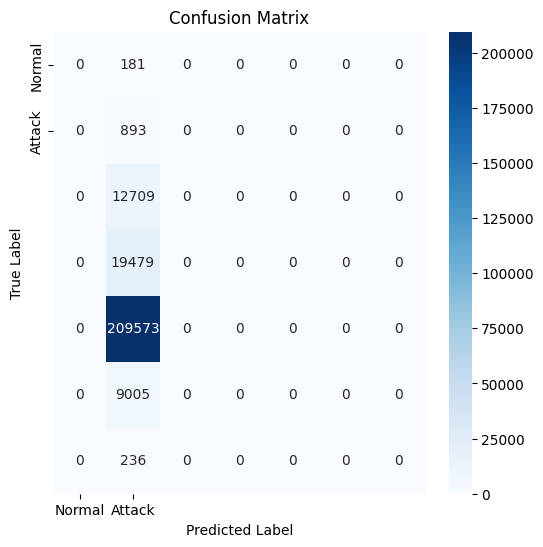

ValueError: multiclass format is not supported

In [34]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import LabelEncoder

# Load the dataset
# Replace with your actual data loading step
df = pd.read_csv('cicids2017_cleaned.csv')

# Example of preprocessing
X = df.drop(columns=['Attack Type'])  # Features
y = df['Attack Type']  # Target

# Encode the target labels using LabelEncoder (converts string to numeric labels)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)  # Converts 'Normal Traffic' to 0, 'Attack' to 1

# Split the dataset into train, validation, and test sets (80%, 10%, 10%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Standardize the features (important for neural networks)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Ensure the data type is float32 (required by TensorFlow)
X_train = X_train.astype(np.float32)
X_val = X_val.astype(np.float32)
X_test = X_test.astype(np.float32)

# Reshape the data for RNN (samples, timesteps, features)
X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_val = X_val.reshape(X_val.shape[0], 1, X_val.shape[1])
X_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

# Check and handle NaN values in the target variable (y_test)
if np.isnan(y_test).any():
    print(f"NaN values detected in y_test. Removing rows with NaN...")
    y_test = y_test[~np.isnan(y_test)]  # Remove NaN entries from y_test
    X_test = X_test[~np.isnan(y_test)]  # Remove corresponding rows from X_test

# Build the RNN model
model = Sequential()

# Add an RNN layer
model.add(SimpleRNN(units=64, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))

# Add dropout to avoid overfitting
model.add(Dropout(0.5))

# Add a Dense layer for binary classification
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_data=(X_val, y_val))


# Check the unique values in y_test and y_pred
print("Unique values in y_test:", np.unique(y_test))
print("Unique values in y_pred:", np.unique(y_pred))

# If the model is working for binary classification, ensure y_pred is binary:
y_pred = (y_pred > 0.5).astype(int)  # Threshold to get binary predictions

# If y_test and y_pred are binary (0 or 1), you can proceed with binary evaluation metrics
if len(np.unique(y_test)) == 2 and len(np.unique(y_pred)) == 2:
    precision = precision_score(y_test, y_pred, average='binary')
    recall = recall_score(y_test, y_pred, average='binary')
    f1 = f1_score(y_test, y_pred, average='binary')
else:
    # If multiclass, adjust the 'average' argument accordingly
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

# Evaluate the metrics
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

# Print evaluation metrics
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')
print(f'Confusion Matrix:\n{conf_matrix}')



'''# Make predictions
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int).flatten()  # Convert predictions to binary class labels and flatten to 1D array

# Ensure y_test is 1D
y_test = y_test.flatten()

# Check for NaN values in y_pred
if np.isnan(y_pred).any():
    print(f"NaN values detected in y_pred. Replacing with 0...")
    y_pred = np.nan_to_num(y_pred)  # Replace NaN values with 0 (or another value if needed)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='binary')  # Specify binary for binary classification
recall = recall_score(y_test, y_pred, average='binary')  # Specify binary for binary classification
f1 = f1_score(y_test, y_pred, average='binary')  # Specify binary for binary classification

# Print evaluation metrics
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')
print(f'Confusion Matrix:\n{conf_matrix}')'''

# Plot Confusion Matrix
plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()

# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

# Plot Precision-Recall Curve
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_pred)

plt.figure(figsize=(6, 6))
plt.plot(recall_curve, precision_curve, color='green', label=f'Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.show()
